# One Provider, Many Doors: What Medicare Facility Affiliations Reveal

This project examines the CMS Facility Affiliation data using the CRISP-DM process. I focus on a practical question: what can a national affiliation file tell us about the breadth of provider networks and the likelihood that a provider works across more than one type of care setting?

## Questions

1. Which facility settings account for the most affiliation records?
2. How broad are individual providers' facility networks?
3. Which primary facility settings are most associated with multi-facility providers?
4. How accurately can a transparent model identify providers whose affiliations cross care settings, and what would it predict in a realistic planning scenario?

The analysis is descriptive and predictive, not causal. It describes affiliations listed in this file and does not measure care quality, access, or patient outcomes.

## 1. Business understanding

Health systems and referral-network teams need to understand how clinicians connect to hospitals, home health agencies, hospices, nursing homes, dialysis facilities, and other settings. A provider whose affiliations cross facility types may be especially relevant when planning care transitions or network outreach.

The modeling goal is therefore to classify whether a summarized provider profile is associated with affiliations in more than one facility type. This is an illustrative screening exercise, not a substitute for reading the complete affiliation record. When the complete facility-type history is available, the outcome should be calculated directly instead of predicted. The model should not be used to rank clinicians, make credentialing decisions, or infer the quality of care.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TEST_SIZE = 0.20
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("data/Facility_Affiliation.csv.gz")
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)
print(f"Using data file: {DATA_PATH}")

Using data file: data/Facility_Affiliation.csv.gz


## 2. Data understanding

In [2]:
def load_affiliation_data(path):
    """Load the CMS facility-affiliation file with identifiers kept as strings."""
    columns = [
        "NPI",
        "Ind_PAC_ID",
        "Provider Last Name",
        "Provider First Name",
        "Provider Middle Name",
        "suff",
        "facility_type",
        "Facility Affiliations Certification Number",
        "Facility Type Certification Number",
    ]
    return pd.read_csv(path, usecols=columns, dtype=str)


affiliations = load_affiliation_data(DATA_PATH)
print(f"Rows: {affiliations.shape[0]:,}")
print(f"Columns: {affiliations.shape[1]}")
print(f"Unique providers (NPI): {affiliations['NPI'].nunique():,}")
facility_column = "Facility Affiliations Certification Number"
print(f"Unique facilities: {affiliations[facility_column].nunique():,}")
display(affiliations.dtypes.rename("data_type").to_frame())
display(
    affiliations[
        [
            "NPI",
            "facility_type",
            "Facility Affiliations Certification Number",
        ]
    ].head(5)
)

Rows: 2,254,034
Columns: 9
Unique providers (NPI): 940,577
Unique facilities: 40,965
                                           data_type
NPI                                           object
Ind_PAC_ID                                    object
Provider Last Name                            object
Provider First Name                           object
Provider Middle Name                          object
suff                                          object
facility_type                                 object
Facility Affiliations Certification Number    object
Facility Type Certification Number            object
          NPI       facility_type Facility Affiliations Certification Number
0  1003000126            Hospital                                     090012
1  1003000142            Hospital                                     360112
2  1003000423            Hospital                                     360098
3  1003000480            Hospital                                     060024


In [3]:
missing_summary = (
    affiliations.isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .to_frame()
)
display(missing_summary)
print("Duplicate rows:", f"{affiliations.duplicated().sum():,}")
print("Facility types:", affiliations["facility_type"].nunique())

                                            missing_percent
NPI                                                    0.00
Ind_PAC_ID                                             0.00
Provider Last Name                                     0.00
Provider First Name                                    0.00
Provider Middle Name                                  34.34
suff                                                  98.45
facility_type                                          0.00
Facility Affiliations Certification Number             0.00
Facility Type Certification Number                    99.61
Duplicate rows: 0
Facility types: 7


### Data quality decisions

- `NPI`, `Ind_PAC_ID`, and certification numbers are identifiers, not quantities, so I load them as strings and preserve leading zeroes.
- The provider middle-name and suffix fields are optional. I do not invent values; I convert their availability into simple presence indicators for modeling.
- `Facility Type Certification Number` is missing for most rows. I retain only a presence indicator because dropping every row with a missing value would remove almost the entire dataset.
- The classification model uses one-hot encoding for the categorical primary facility type and median imputation plus scaling for numeric inputs.
- Provider names are not used by the model. A name should not determine a network-planning classification.

## 3. Data preparation and exploratory analysis

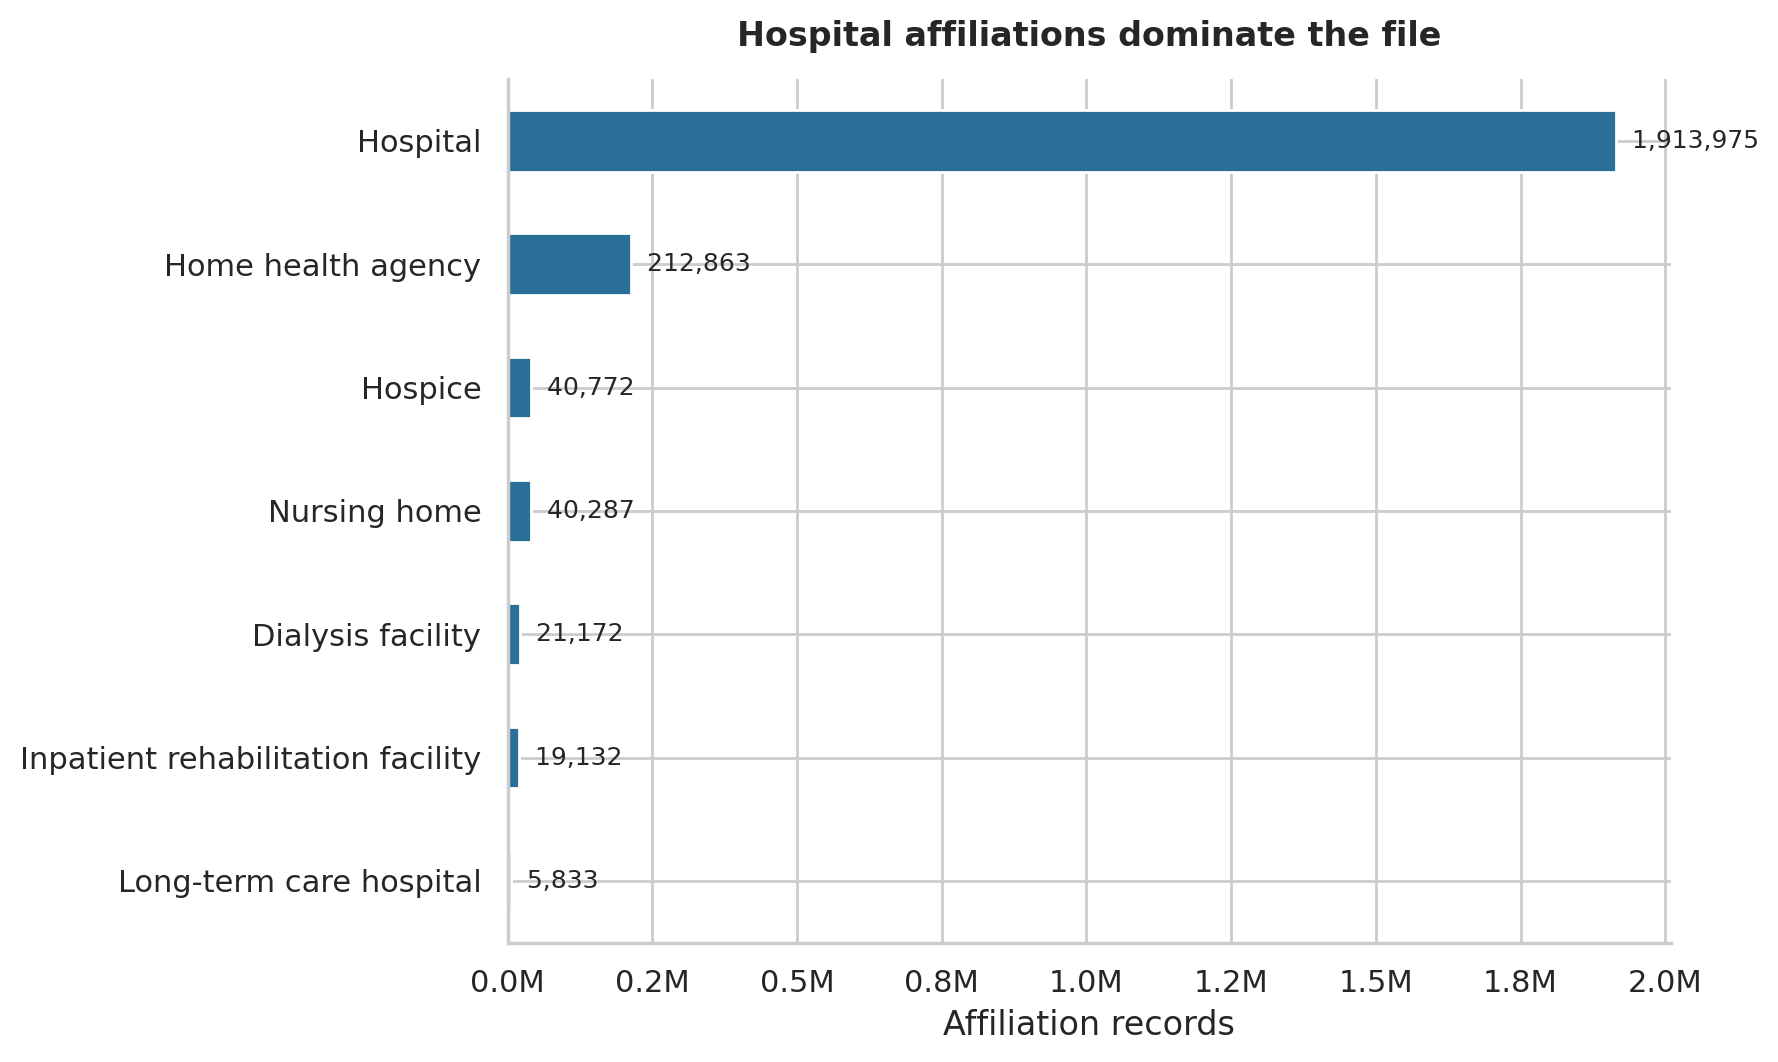

In [4]:
def save_bar_chart(series, title, x_label, file_name, color="#2a6f97"):
    """Plot a labeled horizontal bar chart and save it for the report."""
    fig, ax = plt.subplots(figsize=(9, 5.5))
    series.sort_values().plot.barh(ax=ax, color=color)
    ax.set_title(title, weight="bold", pad=12)
    ax.set_xlabel(x_label)
    ax.set_ylabel("")
    if series.max() >= 1_000_000:
        ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
    elif series.max() >= 1_000:
        ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
    for index, value in enumerate(series.sort_values()):
        ax.text(value, index, f"  {value:,.0f}", va="center", fontsize=9)
    sns.despine(ax=ax)
    fig.tight_layout()
    fig.savefig(IMAGE_DIR / file_name, dpi=200, bbox_inches="tight")
    plt.show()


facility_counts = affiliations["facility_type"].value_counts()
save_bar_chart(
    facility_counts,
    "Hospital affiliations dominate the file",
    "Affiliation records",
    "facility_type_counts.png",
)

### Question 1: Which facility settings account for the most records?

Hospitals account for the clear majority of affiliation records. This matters because national totals can look like a general picture of healthcare while still being driven heavily by one setting. Any comparison across facility types should therefore use both counts and within-type rates rather than raw totals alone.

In [5]:
def build_provider_features(frame):
    """Aggregate affiliation records into one modeling row per NPI."""
    working = frame.copy()
    facility_size = working.groupby(
        "Facility Affiliations Certification Number"
    )["NPI"].nunique()
    working["facility_provider_count"] = working[
        "Facility Affiliations Certification Number"
    ].map(facility_size)

    grouped = working.groupby("NPI", sort=False)
    providers = grouped.agg(
        affiliation_count=("Facility Affiliations Certification Number", "nunique"),
        setting_count=("facility_type", "nunique"),
        facility_provider_mean=("facility_provider_count", "mean"),
        facility_provider_max=("facility_provider_count", "max"),
        middle_name_count=("Provider Middle Name", "count"),
        suffix_count=("suff", "count"),
        type_cert_count=("Facility Type Certification Number", "count"),
    ).reset_index()

    type_frequency = (
        working.groupby(["NPI", "facility_type"], sort=False)
        .size()
        .rename("records")
        .reset_index()
        .sort_values(
            ["NPI", "records", "facility_type"],
            ascending=[True, False, True],
        )
        .drop_duplicates("NPI")
        .set_index("NPI")["facility_type"]
    )
    providers["primary_type"] = providers["NPI"].map(type_frequency)
    providers["has_middle_name"] = (
        providers["middle_name_count"] > 0
    ).astype(int)
    providers["has_suffix"] = (providers["suffix_count"] > 0).astype(int)
    providers["has_type_cert"] = (
        providers["type_cert_count"] > 0
    ).astype(int)
    providers["cross_setting"] = (providers["setting_count"] > 1).astype(int)
    return providers.drop(
        columns=["middle_name_count", "suffix_count", "type_cert_count"]
    )


providers = build_provider_features(affiliations)
display(
    providers[["affiliation_count", "setting_count"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(2)
)
print(
    "Providers with more than one facility affiliation:",
    f"{(providers['affiliation_count'] > 1).mean():.1%}",
)
print(
    "Providers crossing more than one facility setting:",
    f"{providers['cross_setting'].mean():.1%}",
)

       affiliation_count  setting_count
count          940577.00      940577.00
mean                2.40           1.20
std                 1.82           0.52
min                 1.00           1.00
50%                 2.00           1.00
75%                 3.00           1.00
90%                 5.00           2.00
95%                 6.00           2.00
99%                 9.00           3.00
max                23.00           7.00
Providers with more than one facility affiliation: 56.0%
Providers crossing more than one facility setting: 16.1%


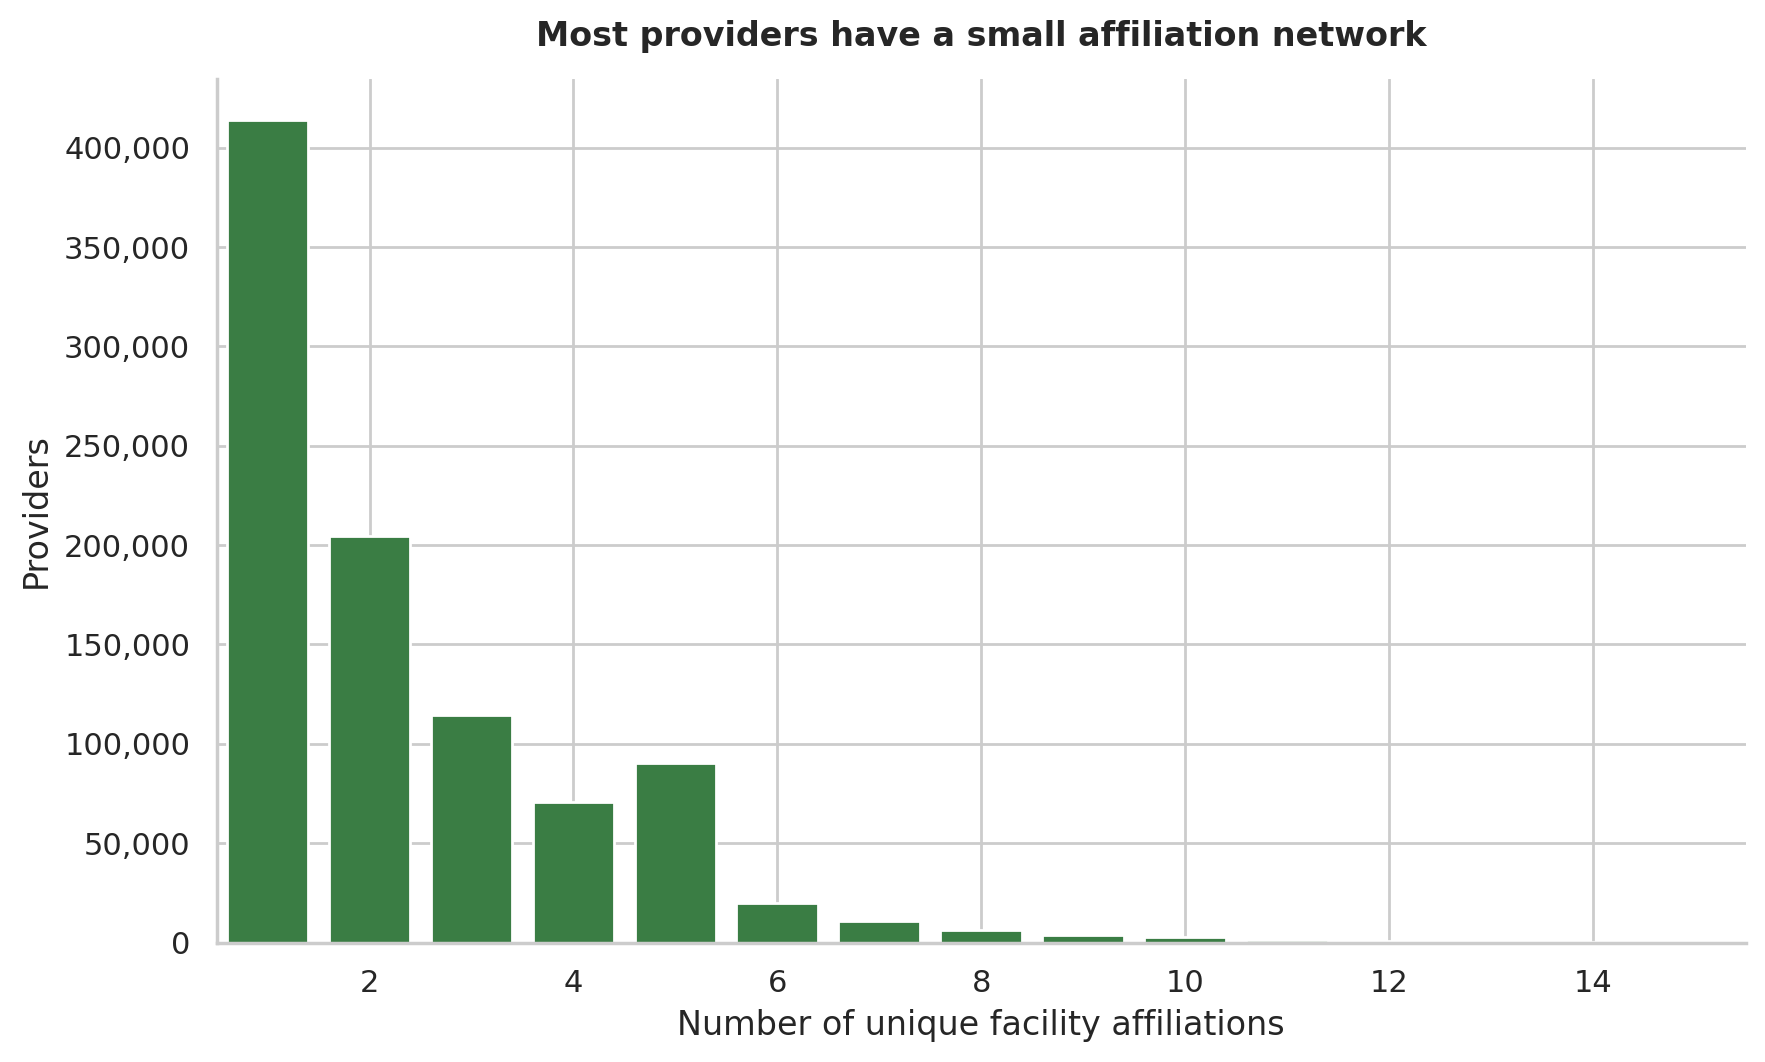

In [6]:
affiliation_distribution = (
    providers["affiliation_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of affiliations")
    .rename("Providers")
)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(
    affiliation_distribution.index,
    affiliation_distribution.values,
    color="#3a7d44",
)
ax.set_title("Most providers have a small affiliation network", weight="bold", pad=12)
ax.set_xlabel("Number of unique facility affiliations")
ax.set_ylabel("Providers")
ax.yaxis.set_major_formatter(lambda value, _: f"{int(value):,}")
ax.set_xlim(0.5, min(15.5, affiliation_distribution.index.max() + 0.5))
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "provider_affiliation_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

### Question 2: How broad are provider networks?

The median provider has two unique facility affiliations, and 56.0% of providers have more than one. The distribution has a long right tail: a small group reaches many facilities, but the typical network is compact. Only 16.1% of providers cross more than one facility setting, which is a stricter and more operationally meaningful definition of network breadth.

                                   percent
primary_type                              
Dialysis facility                     97.7
Home health agency                    91.6
Nursing home                          83.9
Hospice                               83.1
Hospital                              53.1
Inpatient rehabilitation facility     26.5
Long-term care hospital                9.0


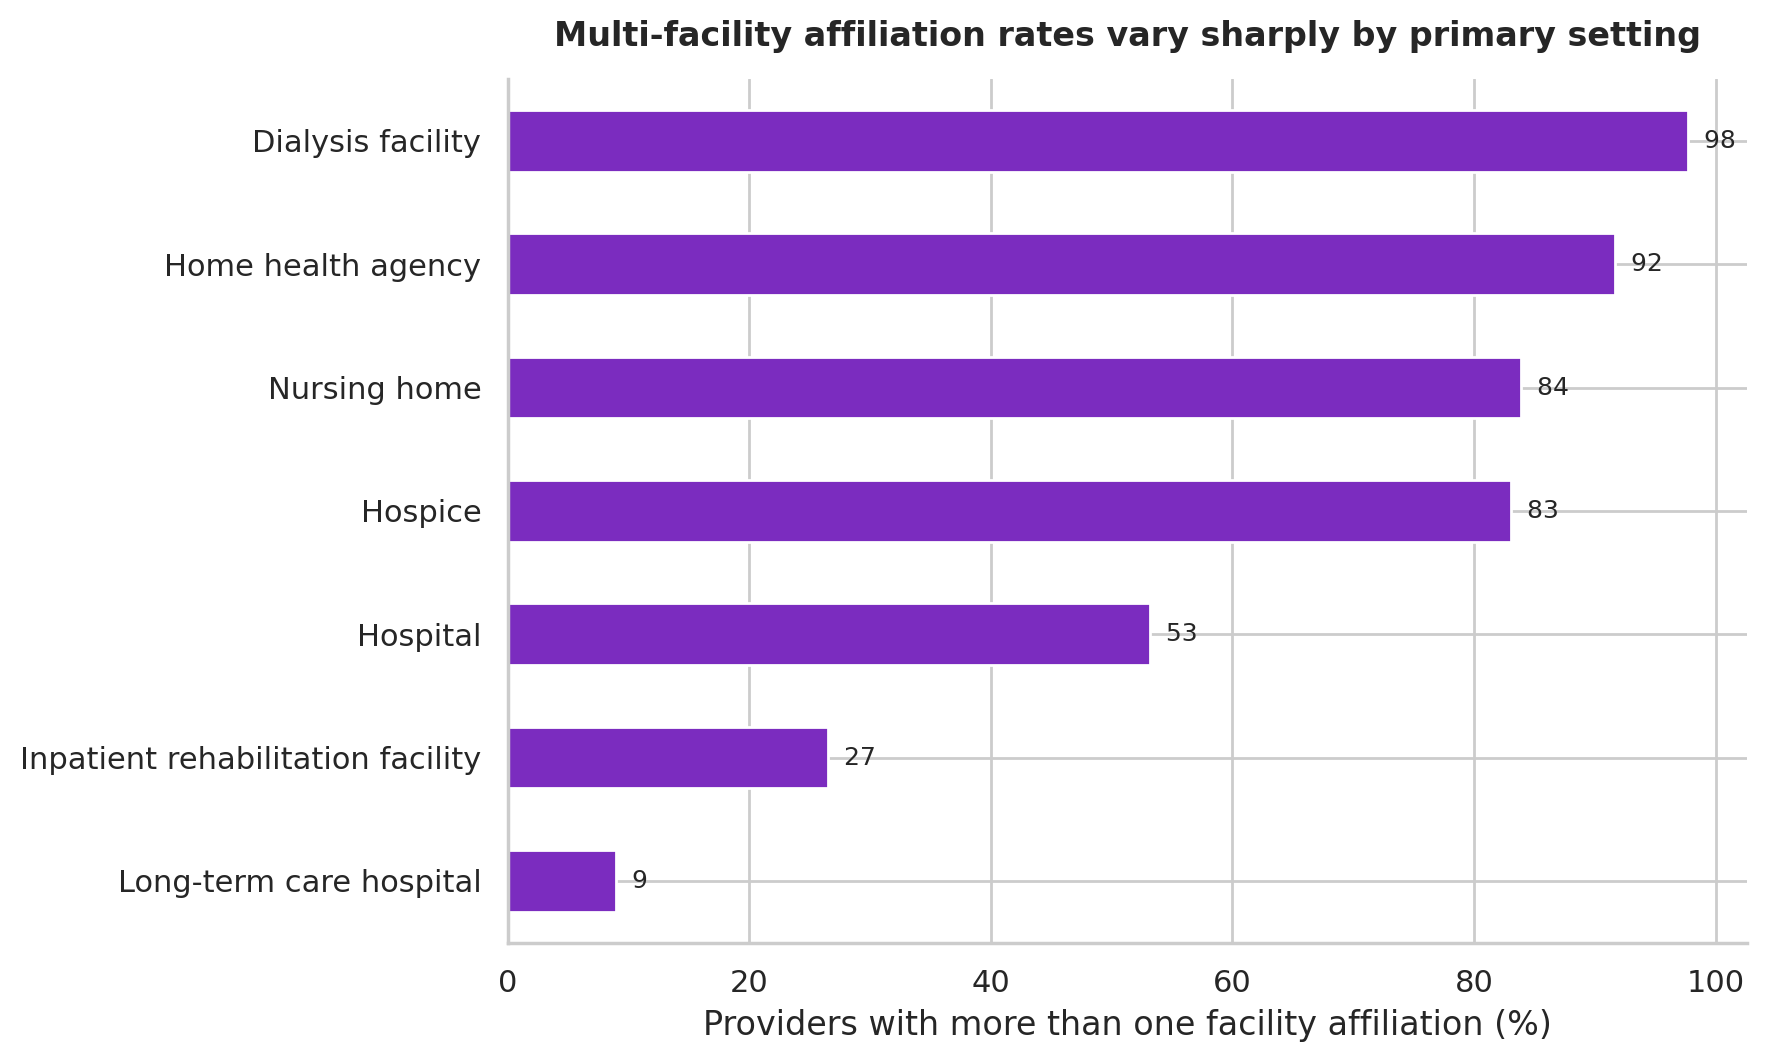

In [7]:
multi_facility_rate = (
    providers.assign(multi_facility=providers["affiliation_count"] > 1)
    .groupby("primary_type")["multi_facility"]
    .mean()
    .mul(100)
)
save_bar_chart(
    multi_facility_rate,
    "Multi-facility affiliation rates vary sharply by primary setting",
    "Providers with more than one facility affiliation (%)",
    "multi_facility_rate_by_type.png",
    color="#7b2cbf",
)
display(multi_facility_rate.sort_values(ascending=False).round(1).to_frame("percent"))

### Question 3: Which settings are most associated with multi-facility providers?

Providers whose primary setting is dialysis, home health, hospice, or nursing home are much more likely to have multiple facility affiliations than providers centered in long-term care hospitals or inpatient rehabilitation facilities. This is not evidence that one setting causes broader networks. It is a descriptive difference that can guide where network teams investigate referral and care-transition patterns first.

## 4. Modeling

In [8]:
FEATURES = [
    "affiliation_count",
    "facility_provider_mean",
    "facility_provider_max",
    "has_middle_name",
    "has_suffix",
    "has_type_cert",
    "primary_type",
]
NUMERIC_FEATURES = FEATURES[:-1]
CATEGORICAL_FEATURES = ["primary_type"]

X = providers[FEATURES]
y = providers["cross_setting"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
    ]
)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
model.fit(X_train, y_train)
print(f"Training providers: {len(X_train):,}")
print(f"Test providers: {len(X_test):,}")

Training providers: 752,461
Test providers: 188,116


           score
Accuracy   0.856
Precision  0.534
Recall     0.830
F1 score   0.650
ROC AUC    0.948
Majority-class baseline accuracy: 0.839


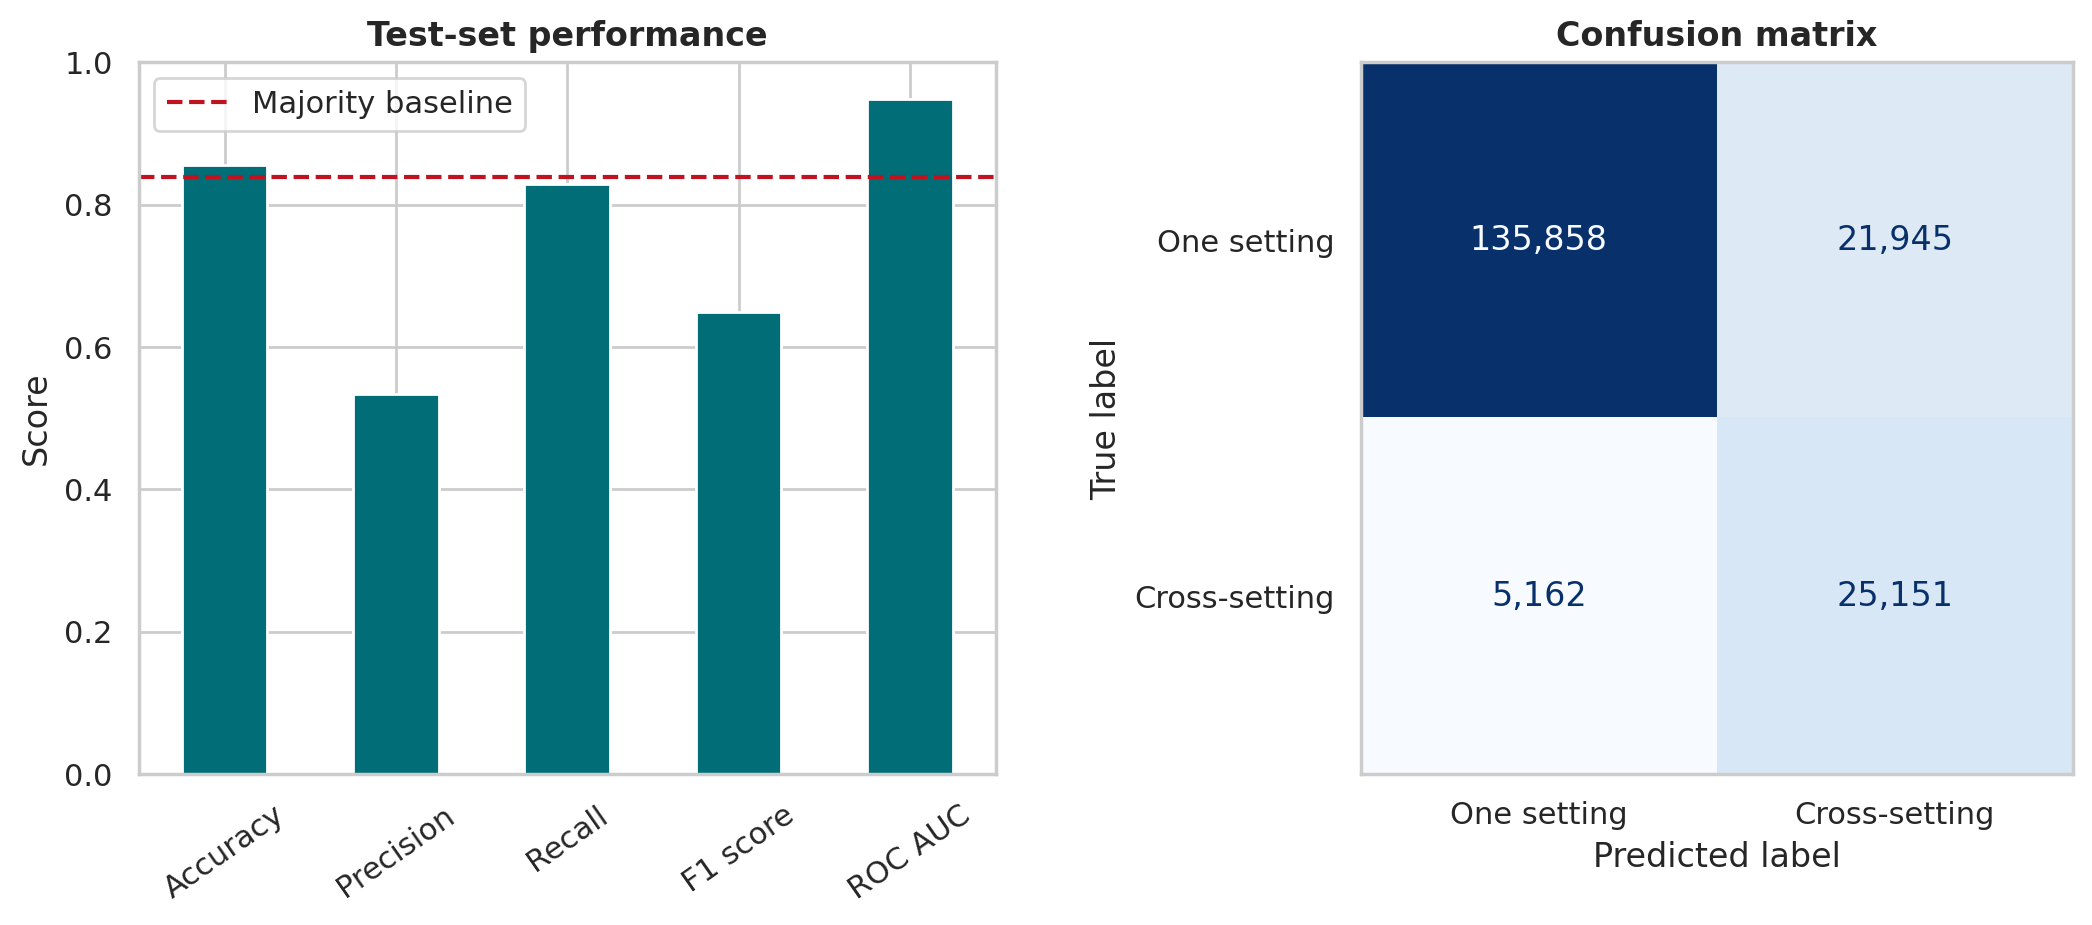

In [9]:
def evaluate_classifier(fitted_model, features, target):
    """Return standard classification metrics and model predictions."""
    predictions = fitted_model.predict(features)
    probabilities = fitted_model.predict_proba(features)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(target, predictions),
        "Precision": precision_score(target, predictions),
        "Recall": recall_score(target, predictions),
        "F1 score": f1_score(target, predictions),
        "ROC AUC": roc_auc_score(target, probabilities),
    }
    return pd.Series(metrics), predictions, probabilities


metrics, predictions, probabilities = evaluate_classifier(model, X_test, y_test)
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
display(metrics.rename("score").round(3).to_frame())
print(f"Majority-class baseline accuracy: {baseline_accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
metrics.plot.bar(ax=axes[0], color="#006d77", ylim=(0, 1))
axes[0].axhline(
    baseline_accuracy,
    color="#c1121f",
    linestyle="--",
    label="Majority baseline",
)
axes[0].set_title("Test-set performance", weight="bold")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["One setting", "Cross-setting"],
    cmap="Blues",
    colorbar=False,
    values_format=",",
    ax=axes[1],
)
axes[1].set_title("Confusion matrix", weight="bold")
axes[1].grid(False)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "model_performance.png", dpi=200, bbox_inches="tight")
plt.show()

                                            feature  coefficient
1                            Facility provider mean       -2.531
6                   Primary type: dialysis facility        2.395
7                  Primary type: home health agency        2.136
9                            Primary type: hospital       -2.135
8                             Primary type: hospice        1.905
11            Primary type: long-term care hospital       -1.808
10  Primary type: inpatient rehabilitation facility       -1.640
2                             Facility provider max        1.530
0                                 Affiliation count        1.504
5                                     Has type cert        0.556
12                       Primary type: nursing home       -0.550
3                                   Has middle name        0.087


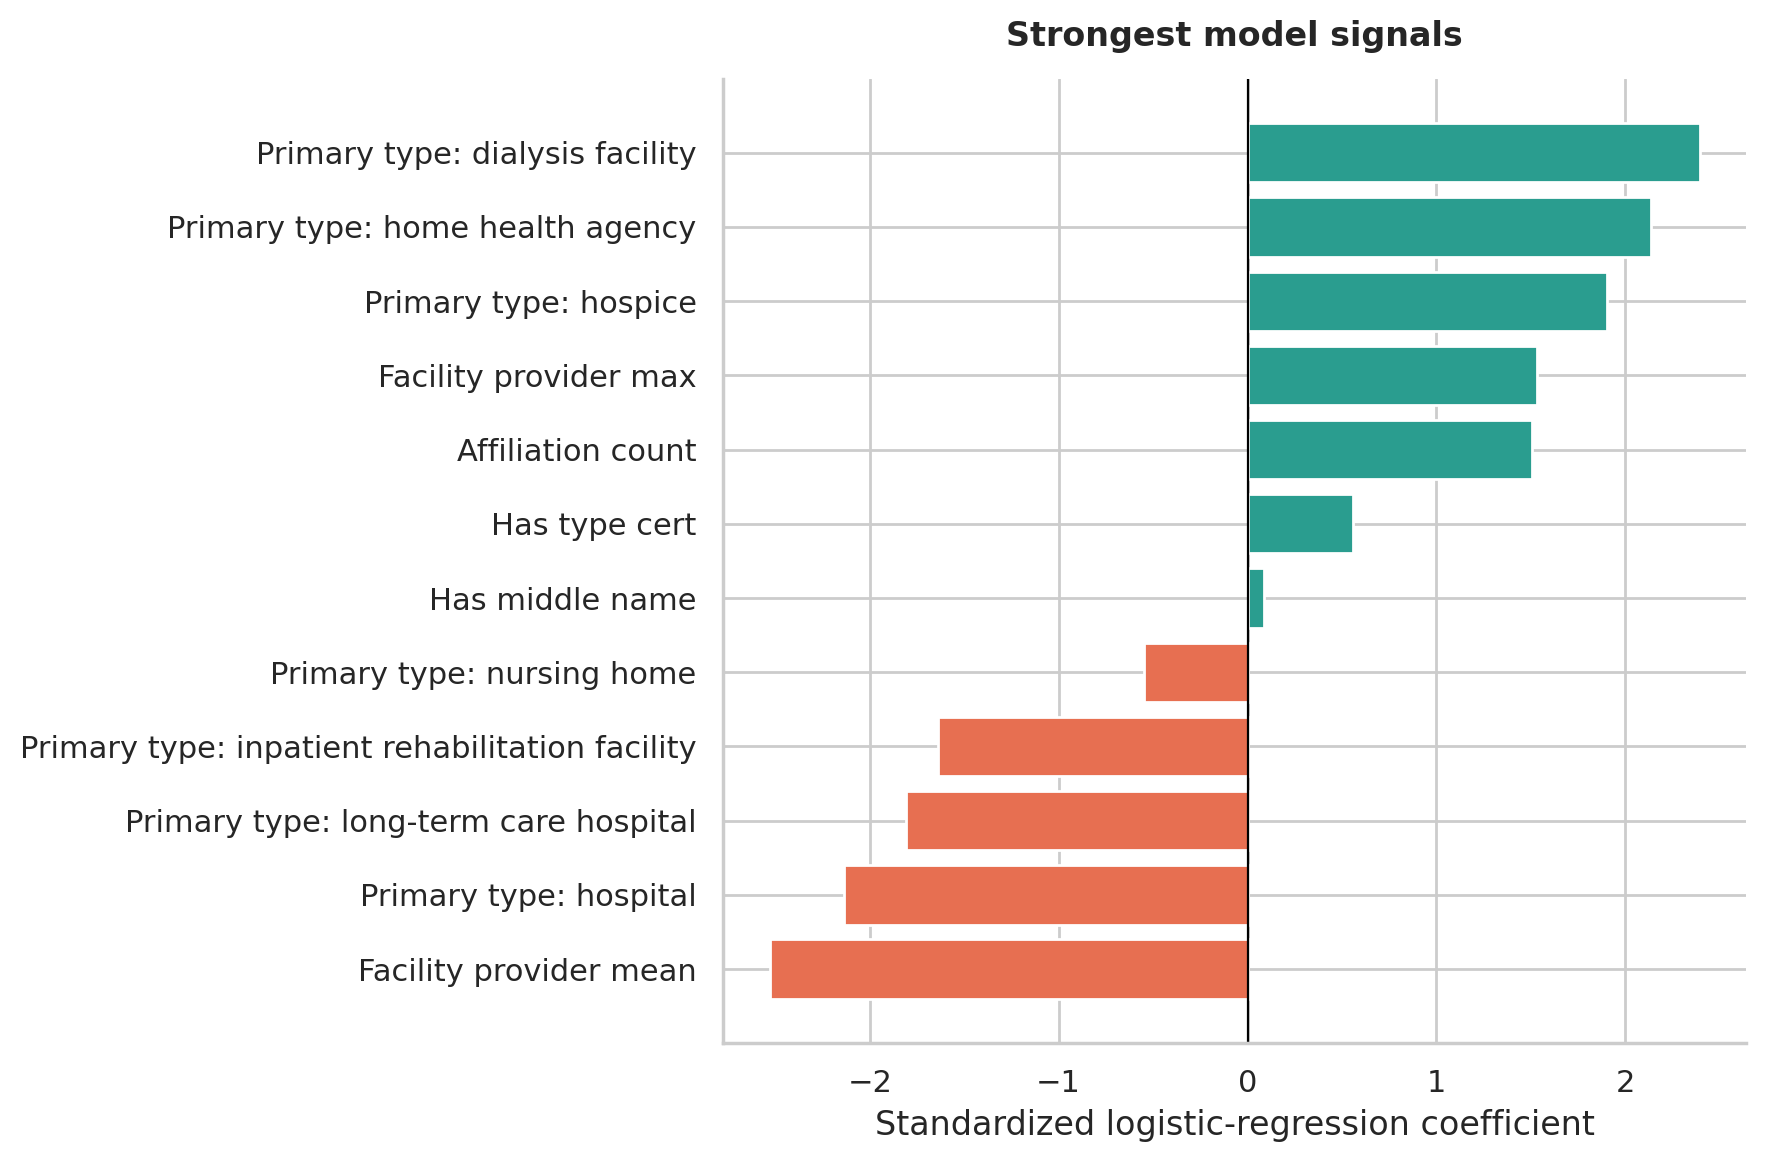

In [10]:
raw_feature_names = model.named_steps["preprocessor"].get_feature_names_out()
feature_names = (
    pd.Series(raw_feature_names)
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__primary_type_", "Primary type: ", regex=False)
    .str.replace("_", " ", regex=False)
    .str.capitalize()
    .to_numpy()
)
coefficients = model.named_steps["classifier"].coef_[0]
coefficient_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
top_coefficients = coefficient_table.head(12).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(top_coefficients["coefficient"] >= 0, "#2a9d8f", "#e76f51")
ax.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Strongest model signals", weight="bold", pad=12)
ax.set_xlabel("Standardized logistic-regression coefficient")
ax.set_ylabel("")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "model_feature_signals.png", dpi=200, bbox_inches="tight")
plt.show()
display(coefficient_table.head(12)[["feature", "coefficient"]].round(3))

### Question 4: How accurate is the model, and what drives its prediction?

On the held-out test set, the model reaches **85.6% accuracy**, **83.0% recall**, **65.0% F1**, and **0.948 ROC AUC**. Accuracy is only **1.7 percentage points** above the 83.9% majority-class baseline, so accuracy alone would overstate the achievement. Recall shows that the model finds most cross-setting providers. Precision shows that only 53.4% of the profiles it flags are actually cross-setting. ROC AUC measures ranking ability across possible decision thresholds; 0.948 means the model separates the two groups well even though the default threshold still produces false alarms.

The strongest signals are the breadth of a provider's affiliation network, characteristics of the connected facilities, and the provider's primary facility setting. More affiliations and a larger maximum connected-facility size push the prediction toward cross-setting. A high average connected-facility size pushes in the opposite direction after the other variables are held constant. Several primary-setting categories also shift the odds. These are associations learned from this file, not proof of cause.

## 5. Creative prediction scenario

Predicted probability of cross-setting affiliations: 56.8%
   affiliation_count  facility_provider_mean  facility_provider_max  has_middle_name  has_suffix  has_type_cert primary_type
0                  4                   820.5                 1511.0                1           0              0     Hospital


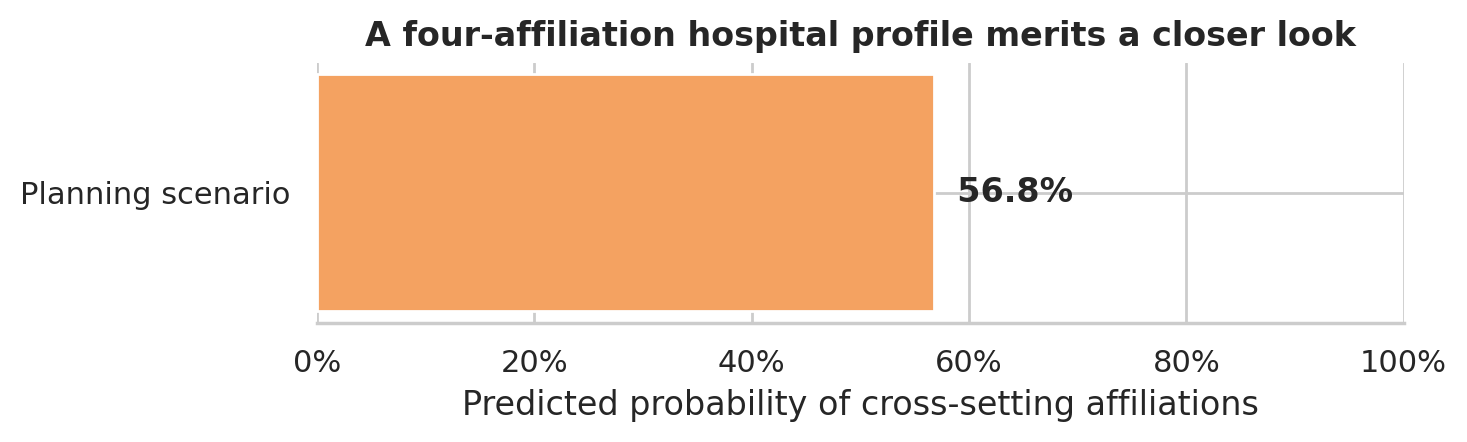

In [11]:
hospital_reference = providers[
    (providers["primary_type"] == "Hospital")
    & (providers["affiliation_count"] == 4)
]
scenario = pd.DataFrame(
    [
        {
            "affiliation_count": 4,
            "facility_provider_mean": hospital_reference[
                "facility_provider_mean"
            ].median(),
            "facility_provider_max": hospital_reference[
                "facility_provider_max"
            ].median(),
            "has_middle_name": 1,
            "has_suffix": 0,
            "has_type_cert": 0,
            "primary_type": "Hospital",
        }
    ]
)
scenario_probability = model.predict_proba(scenario)[0, 1]
print(
    "Predicted probability of cross-setting affiliations:",
    f"{scenario_probability:.1%}",
)
display(scenario.round(1))

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(["Planning scenario"], [scenario_probability], color="#f4a261")
ax.set_xlim(0, 1)
ax.set_xlabel("Predicted probability of cross-setting affiliations")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.text(
    scenario_probability,
    0,
    f"  {scenario_probability:.1%}",
    va="center",
    weight="bold",
)
ax.set_title("A four-affiliation hospital profile merits a closer look", weight="bold")
sns.despine(ax=ax, left=True)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "scenario_prediction.png", dpi=200, bbox_inches="tight")
plt.show()

Imagine a regional network team receives a summarized provider profile centered on a hospital and linked to four facilities, but the setting details are temporarily unavailable. Using median facility-size values from similar hospital-centered providers, the model estimates the probability shown above that this provider's network crosses care settings.

The team could use that score to prioritize manual network review, not to make an automatic decision. A reviewer would verify the underlying affiliations, check whether the source file is current, and then decide whether the provider is relevant to care-transition planning. If the complete facility-type fields are available, the team should calculate the answer directly and skip the model.

## 6. Evaluation, limitations, and deployment considerations

- The file is an administrative snapshot. It does not show when an affiliation began, how often a provider works at a facility, or whether patients move between those facilities.
- The classes are imbalanced: only 16.1% of providers are cross-setting. That is why I report precision, recall, F1, and ROC AUC in addition to accuracy.
- `class_weight='balanced'` improves attention to the minority class, but the resulting probabilities are not automatically calibrated. A production system would calibrate probabilities and choose a threshold based on the cost of missed versus unnecessary reviews.
- The outcome is already observable when complete facility-type records are present. The model has value only as a limited screening demonstration when a summarized profile arrives before those details. It is not a future-behavior forecast.
- Coefficients describe conditional associations in this model. They should not be interpreted as causal effects.
- Provider names and raw identifiers are excluded from training. A deployment should also apply access controls, audit logging, data freshness checks, and human review.

## 7. CRISP-DM summary

1. **Business understanding:** identify useful signals for care-setting network review.
2. **Data understanding:** inspect 2.25 million affiliation records, seven facility types, missingness, and identifier semantics.
3. **Data preparation:** aggregate to one row per NPI, preserve identifiers as strings, create documented features, encode categories, and split the provider-level table.
4. **Modeling:** fit a transparent, class-weighted logistic regression.
5. **Evaluation:** compare accuracy with the majority baseline and examine precision, recall, F1, ROC AUC, coefficients, and the confusion matrix.
6. **Deployment:** use predictions only to prioritize human review, with monitoring for drift, calibration, and changes in CMS reporting.

## Data source

Centers for Medicare & Medicaid Services, [Facility Affiliation Data](https://data.cms.gov/provider-data/dataset/27ea-46a8), accessed September 12, 2026.